#### Seaborn
Seaborn ek data visualization library hai.Ye Matplotlib ke upar built hai jst like pandas is built on numpy, so its super easy to integrate seaborn with matplotlib. You might think why to learn another lib well if we go back to the plot from last ex its great but i want the graph to be more colourful i.e more high paying skills should be kind off darker than less paying skills etc. this is slightly diff in matplot than seaborn. It enhances all the plots and make them visually appealing. You can checkout its documentation home page and inspect the underneath gallery 

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
import seaborn as sns

In [ ]:
df_DA_India = df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='India')]

df_DA_India=df_DA_India.dropna(subset='salary_year_avg')

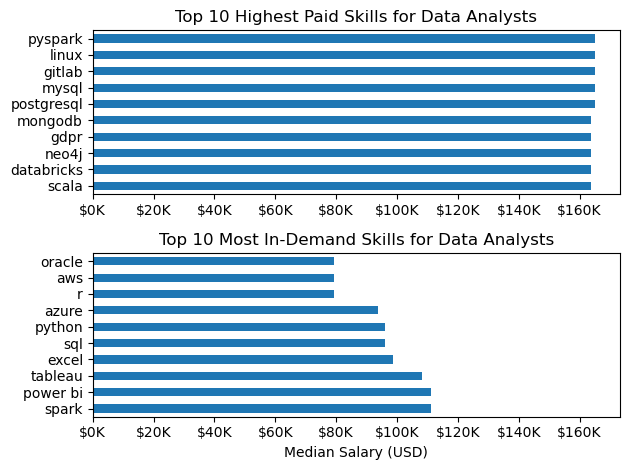

In [5]:
df_DA_India = df_DA_India.explode('job_skills')

df_DA_India_group = df_DA_India.groupby('job_skills')['salary_year_avg'].agg(['median','count'])

df_DA_top_pay = df_DA_India_group.sort_values(by='median',ascending=False).head(10)

df_DA_top_skills = df_DA_India_group.sort_values(by='count',ascending=False).head(10).sort_values(by='median',ascending=False)

fig, ax= plt.subplots(2,1)

df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
# ax[0].invert_yaxis() this is used to invert y axis but another method to invert y axis is [::-1as we will strt from bottom]
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

df_DA_top_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim()) #this will set xlim similar to ax[0]'s lim
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()

<div style='font-size:14px'>so in seaborn we use hue to set according to which data should shade chnge it contains lot of colour palattes you can go through its documentation for everything 

<div style='font-size:14px'>we can also alter the themes of the graphs itself jst by specifying set theme and then from there apecifying a tyle 

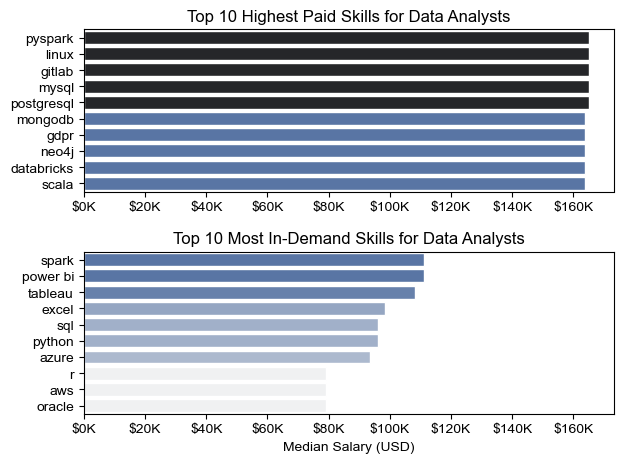

In [10]:
fig, ax= plt.subplots(2,1)
sns.set_theme(style='ticks')

# Top 10 highest Paid Skills for Data Analyst
sns.barplot(data=df_DA_top_pay,x='median',y=df_DA_top_pay.index, ax=ax[0], hue='median',palette='dark:b_r') #palette mai color ke aage _r add krne se pura reverse hojata hai color
# df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 most In-Demand Skills for Data Analyst
sns.barplot(data=df_DA_top_skills,x='median',y=df_DA_top_skills.index, ax=ax[1], hue='median',palette='light:b')
ax[1].legend().remove()

# df_DA_top_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim()) #this will set xlim similar to ax[0]'s lim
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()

<div style='font-size:14px'>now we will do the same for histogram.navigate to hist plot ,it is for histogram we don't want to plot it like its given in doc nder hist plot so we will plot this with displot cz we want smooth curves 

Text(0, 0.5, 'Number of Jobs')

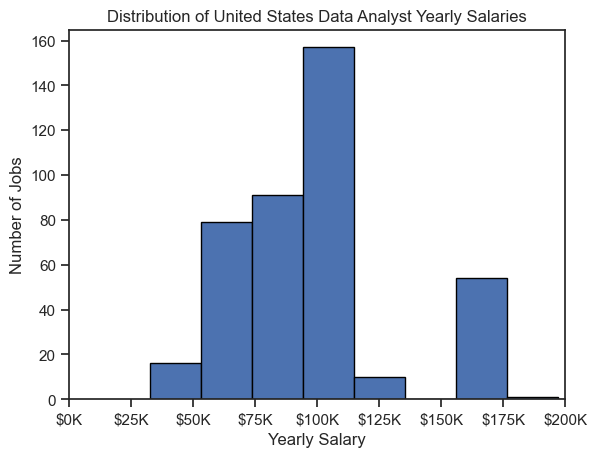

In [11]:
df_DA_India['salary_year_avg'].plot(kind='hist',bins=30,edgecolor='black')
plt.xlim(0,200000)

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')

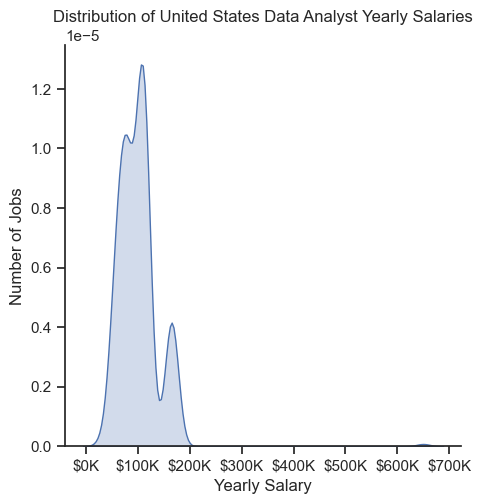

In [15]:
sns.displot(df_DA_India['salary_year_avg'],kind='kde',fill=True)
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

<div style='font-size:14px'>now we will do the same for boxplot but its slightly diff for bp graphs....DOUBT cz boxplot is DOUBT